## 0. Install Dependencies

In [ ]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 22.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports

In [ ]:
import json
import os
import re
import shutil
import time
import unicodedata
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import httpx
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import whisper
from difflib import SequenceMatcher
from IPython.display import display, Image
matplotlib.use("Agg")

## 2. Configuration — Fill in your API keys and dataset path here

In [ ]:
# API Keys
DEEPGRAM_API_KEY="please put api key"
SARVAM_API_KEY="please put api key"
AUDIO_DIR = "./audio_samples"
MODELS_TO_RUN = ["deepgram", "whisper", "sarvam"]
WHISPER_MODEL_SIZE = "large-v3"
RESULTS_OUTPUT = "./output/benchmark_results.json"

## 3. Metrics (WER · CER · LEA)

In [5]:
def normalise(text: str) -> str:
    text = text.lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _levenshtein_tokens(ref: List[str], hyp: List[str]) -> Tuple[int, int, int, int]:
    r, h = len(ref), len(hyp)
    dp = [[0] * (h + 1) for _ in range(r + 1)]
    for i in range(r + 1): dp[i][0] = i
    for j in range(h + 1): dp[0][j] = j
    for i in range(1, r + 1):
        for j in range(1, h + 1):
            if ref[i-1] == hyp[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    i, j = r, h
    S = D = I = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and ref[i-1] == hyp[j-1]:
            i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            S += 1; i -= 1; j -= 1
        elif i > 0 and dp[i][j] == dp[i-1][j] + 1:
            D += 1; i -= 1
        else:
            I += 1; j -= 1
    return S, D, I, r


def _levenshtein_chars(ref: str, hyp: str) -> Tuple[int, int, int, int]:
    return _levenshtein_tokens(list(ref), list(hyp))


def wer(reference: str, hypothesis: str) -> float:
    ref = normalise(reference).split()
    hyp = normalise(hypothesis).split()
    if not ref: return 0.0 if not hyp else 1.0
    S, D, I, N = _levenshtein_tokens(ref, hyp)
    return (S + D + I) / N


def cer(reference: str, hypothesis: str) -> float:
    ref = normalise(reference)
    hyp = normalise(hypothesis)
    if not ref: return 0.0 if not hyp else 1.0
    S, D, I, N = _levenshtein_chars(ref, hyp)
    return (S + D + I) / N


def _token_set(text: str) -> set:
    return set(normalise(text).split())


def locality_overlap(locality: str, hypothesis: str) -> float:
    loc_tokens = _token_set(locality)
    hyp_tokens = _token_set(hypothesis)
    if not loc_tokens: return 1.0
    intersection = loc_tokens & hyp_tokens
    union = loc_tokens | hyp_tokens
    return len(intersection) / len(union) if union else 0.0


def locality_exact_match(locality: str, hypothesis: str) -> bool:
    return _token_set(locality).issubset(_token_set(hypothesis))


def locality_fuzzy_match(locality: str, hypothesis: str, threshold: float = 0.6) -> bool:
    loc_norm = normalise(locality)
    hyp_norm = normalise(hypothesis)
    if SequenceMatcher(None, loc_norm, hyp_norm).ratio() >= threshold:
        return True
    loc_words = loc_norm.split()
    hyp_words = hyp_norm.split()
    w = len(loc_words)
    for start in range(max(1, len(hyp_words) - w + 1)):
        window = " ".join(hyp_words[start:start + w])
        if SequenceMatcher(None, loc_norm, window).ratio() >= threshold:
            return True
    return False


def compute_batch_metrics(
    samples: List[Dict],
    model_name: str,
    predictions: List[str],
    latencies_ms: Optional[List[float]] = None,
) -> Dict:
    assert len(samples) == len(predictions)
    per_sample = []
    wer_scores, cer_scores, exact_hits, fuzzy_hits, overlaps = [], [], [], [], []

    for sample, pred in zip(samples, predictions):
        ref      = sample["sentence"]
        locality = sample["locality"]
        w = wer(ref, pred or "")
        c = cer(ref, pred or "")
        exact   = locality_exact_match(locality, pred or "")
        fuzzy   = locality_fuzzy_match(locality, pred or "")
        overlap = locality_overlap(locality, pred or "")
        wer_scores.append(w); cer_scores.append(c)
        exact_hits.append(int(exact)); fuzzy_hits.append(int(fuzzy))
        overlaps.append(overlap)
        per_sample.append({
            "index": sample["index"], "locality": locality,
            "condition": sample["condition"], "reference": ref,
            "hypothesis": pred or "", "wer": round(w, 4), "cer": round(c, 4),
            "locality_exact": exact, "locality_fuzzy": fuzzy,
            "locality_overlap": round(overlap, 4),
        })

    n = len(samples)
    result = {
        "model": model_name, "n_samples": n,
        "mean_wer": round(sum(wer_scores) / n, 4),
        "mean_cer": round(sum(cer_scores) / n, 4),
        "locality_exact_accuracy": round(sum(exact_hits) / n, 4),
        "locality_fuzzy_accuracy": round(sum(fuzzy_hits) / n, 4),
        "mean_locality_overlap": round(sum(overlaps) / n, 4),
        "per_sample": per_sample,
    }
    if latencies_ms:
        result["mean_latency_ms"] = round(sum(latencies_ms) / len(latencies_ms), 1)
        result["p95_latency_ms"]  = round(sorted(latencies_ms)[int(0.95 * len(latencies_ms))], 1)

    conditions = sorted(set(s["condition"] for s in samples))
    condition_breakdown = {}
    for cond in conditions:
        idxs = [i for i, s in enumerate(samples) if s["condition"] == cond]
        if not idxs: continue
        condition_breakdown[cond] = {
            "n": len(idxs),
            "mean_wer": round(sum(wer_scores[i] for i in idxs) / len(idxs), 4),
            "locality_exact_accuracy": round(sum(exact_hits[i] for i in idxs) / len(idxs), 4),
        }
    result["condition_breakdown"] = condition_breakdown
    return result


print("Metrics module loaded.")

Metrics module loaded.


## 4. ASR Runners — Real API calls, no simulation

In [6]:
def run_deepgram(filepath: str) -> Tuple[str, float]:
    if not DEEPGRAM_API_KEY or DEEPGRAM_API_KEY == "YOUR_DEEPGRAM_API_KEY_HERE":
        raise RuntimeError("Set DEEPGRAM_API_KEY in the Configuration cell.")

    url = (
        "https://api.deepgram.com/v1/listen"
        "?model=nova-2-general"
        "&language=hi"
        "&punctuate=true"
        "&diarize=false"
        "&detect_language=true"
    )
    with open(filepath, "rb") as f:
        audio_bytes = f.read()

    req = urllib.request.Request(
        url, data=audio_bytes,
        headers={"Authorization": f"Token {DEEPGRAM_API_KEY}", "Content-Type": "audio/wav"},
        method="POST",
    )
    start = time.perf_counter()
    with urllib.request.urlopen(req, timeout=30) as resp:
        latency_ms = (time.perf_counter() - start) * 1000
        body = json.loads(resp.read())
    transcript = (
        body.get("results", {})
            .get("channels", [{}])[0]
            .get("alternatives", [{}])[0]
            .get("transcript", "")
    )
    return transcript, latency_ms



_whisper_model_cache = {}

def run_whisper(filepath: str) -> Tuple[str, float]:
    if WHISPER_MODEL_SIZE not in _whisper_model_cache:
        print(f"  Loading Whisper {WHISPER_MODEL_SIZE} (first time only)...")
        _whisper_model_cache[WHISPER_MODEL_SIZE] = whisper.load_model(
            WHISPER_MODEL_SIZE, download_root="/kaggle/working/models"
        )
    model = _whisper_model_cache[WHISPER_MODEL_SIZE]
    start = time.perf_counter()
    result = model.transcribe(filepath, language="hi", task="transcribe")
    latency_ms = (time.perf_counter() - start) * 1000
    return result["text"].strip(), latency_ms


def run_sarvam(filepath: str) -> Tuple[str, float]:
    if not SARVAM_API_KEY or SARVAM_API_KEY == "YOUR_SARVAM_API_KEY_HERE":
        raise RuntimeError("Set SARVAM_API_KEY in the Configuration cell.")
    with open(filepath, "rb") as f:
        audio_bytes = f.read()

    start = time.perf_counter()
    resp = httpx.post(
        "https://api.sarvam.ai/speech-to-text",
        headers={"api-subscription-key": SARVAM_API_KEY},
        files={"file": ("audio.wav", audio_bytes, "audio/wav")},
        data={"language_code": "hi-IN", "model": "saarika:v1"},
        timeout=30,
    )
    latency_ms = (time.perf_counter() - start) * 1000
    return resp.json().get("transcript", ""), latency_ms

MODEL_REGISTRY = {
    "deepgram": {
        "fn": run_deepgram,
        "display": "Deepgram Nova-2",
        "type": "API",
        "cost_per_min_usd": 0.0059,
        "streaming": True,
        "languages": ["hi", "en", "multi"],
    },
    "whisper": {
        "fn": run_whisper,
        "display": "Whisper Large-v3",
        "type": "Open-source",
        "cost_per_min_usd": 0.0,
        "streaming": False,
        "languages": ["multi (99 lang)"],
    },
    "sarvam": {
        "fn": run_sarvam,
        "display": "Sarvam AI Saarika",
        "type": "API",
        "cost_per_min_usd": 0.004,
        "streaming": True,
        "languages": ["hi", "kn", "ta", "te", "bn", "indic"],
    },
}

print("ASR runners loaded.")

ASR runners loaded.


## 5. Load Manifest

In [7]:
audio_dir = Path(AUDIO_DIR)
manifest_path = audio_dir / "manifest.json"

if not manifest_path.exists():
    raise FileNotFoundError(
        f"manifest.json not found at {manifest_path}\n"
        "Make sure you attached the audio dataset and set AUDIO_DIR correctly."
    )

samples = json.loads(manifest_path.read_text(encoding="utf-8"))
print(f"Loaded {len(samples)} samples from manifest.")
print(f"Conditions: {sorted(set(s['condition'] for s in samples))}")
print(f"Localities: {[s['locality'] for s in samples]}")

Loaded 20 samples from manifest.
Conditions: ['clean', 'phone_call', 'rushed', 'street_noise', 'whispered']
Localities: ['Koramangala', 'Indiranagar', 'Whitefield', 'Electronic City', 'Marathahalli', 'Jayanagar', 'Rajajinagar', 'Hebbal', 'Yelahanka', 'Banashankari', 'Byatarayanapura', 'Kadugondanahalli', 'Hesaraghatta', 'Chikkabanavara', 'Rajarajeshwarinagar', 'Kothanur Dinne', 'Thanisandra', 'KR Puram', 'Peenya', 'Yeshwanthpur']


## 6. Run Benchmark

In [8]:
def run_model_on_all(model_key: str, samples: list) -> dict:
    model_info = MODEL_REGISTRY[model_key]
    fn = model_info["fn"]
    display = model_info["display"]

    print(f"\n{'─'*60}")
    print(f"Running: {display}")
    print(f"{'─'*60}")

    predictions, latencies = [], []

    for sample in samples:
        filepath = str(audio_dir / sample["filename"])
        print(f"  [{sample['index']:02d}/20] {sample['locality']:20s} ({sample['condition']}) ... ",
              end="", flush=True)

        if not os.path.exists(filepath):
            print("FILE NOT FOUND — skipping")
            predictions.append("")
            latencies.append(-1.0)
            continue

        try:
            transcript, latency = fn(filepath)
        except Exception as e:
            print(f"ERROR: {e}")
            predictions.append("")
            latencies.append(-1.0)
            continue

        preview = transcript[:60] + "..." if len(transcript) > 60 else transcript
        print(f"{latency:.0f}ms → \"{preview}\"")
        predictions.append(transcript)
        latencies.append(latency)

    valid_latencies = [l for l in latencies if l > 0]
    metrics = compute_batch_metrics(
        samples=samples,
        model_name=display,
        predictions=predictions,
        latencies_ms=valid_latencies or None,
    )
    metrics["model_key"] = model_key
    metrics["model_meta"] = {
        "type": model_info["type"],
        "cost_per_min_usd": model_info["cost_per_min_usd"],
        "streaming": model_info["streaming"],
        "languages": model_info["languages"],
    }

    # Per-model summary
    print(f"\n  WER={metrics['mean_wer']:.2%}  "
          f"CER={metrics['mean_cer']:.2%}  "
          f"LEA-exact={metrics['locality_exact_accuracy']:.2%}  "
          f"LEA-fuzzy={metrics['locality_fuzzy_accuracy']:.2%}"
          + (f"  latency={metrics['mean_latency_ms']}ms" if "mean_latency_ms" in metrics else ""))
    return metrics


all_results = []
for key in MODELS_TO_RUN:
    result = run_model_on_all(key, samples)
    all_results.append(result)

print("\nBenchmark complete.")


────────────────────────────────────────────────────────────
Running: Deepgram Nova-2
────────────────────────────────────────────────────────────
  [01/20] Koramangala          (clean) ... 462ms → ""
  [02/20] Indiranagar          (street_noise) ... 559ms → ""
  [03/20] Whitefield           (phone_call) ... 457ms → ""
  [04/20] Electronic City      (street_noise) ... 856ms → "Merhaba Fez Elektronik Södime."
  [05/20] Marathahalli         (rushed) ... 678ms → ""
  [06/20] Jayanagar            (clean) ... 1968ms → ""
  [07/20] Rajajinagar          (street_noise) ... 2306ms → ""
  [08/20] Hebbal               (phone_call) ... 381ms → ""
  [09/20] Yelahanka            (whispered) ... 775ms → "यह लहंका जा रहा है क्यों?"
  [10/20] Banashankari         (whispered) ... 2293ms → ""
  [11/20] Byatarayanapura      (clean) ... 851ms → ""
  [12/20] Kadugondanahalli     (street_noise) ... 274ms → ""
  [13/20] Hesaraghatta         (phone_call) ... 941ms → ""
  [14/20] Chikkabanavara       (whispere

100%|██████████████████████████████████████| 2.88G/2.88G [00:23<00:00, 133MiB/s]


4655ms → "कॉल मंगला मेरे तुम कॉल मंगला"
  [02/20] Indiranagar          (street_noise) ... 2006ms → "इंदिरनगर से हूँ जाराओं इंदिरनगर"
  [03/20] Whitefield           (phone_call) ... 2274ms → "वाइट फिल्ड, वाइट फिल्ड मैं जा रहा हूँ"
  [04/20] Electronic City      (street_noise) ... 1841ms → "मेरा ओफिस एलेक्ट्रोनिक सिटी में है"
  [05/20] Marathahalli         (rushed) ... 1472ms → "मारा था हली में जाते हैं चल"
  [06/20] Jayanagar            (clean) ... 1851ms → "जयनागा जा रहा है, क्यों?"
  [07/20] Rajajinagar          (street_noise) ... 2131ms → "रजाजी नगर कहा है ये कहा है रजाजी नगर"
  [08/20] Hebbal               (phone_call) ... 2091ms → "हिब्बल जा रहे हैं तेरा घर हिब्बल में है"
  [09/20] Yelahanka            (whispered) ... 1524ms → "कि यह लाभ का जाना चाहिए अ"
  [10/20] Banashankari         (whispered) ... 1920ms → "तू बनाशंकारी में हैं, वो कहाँ हैं?"
  [11/20] Byatarayanapura      (clean) ... 1472ms → "प्यातरायानापुरा ये काहे"
  [12/20] Kadugondanahalli     (street_noise) ... 2018ms → "

## 7. Results Summary Tables

In [9]:
print("\n" + "="*85)
print("FINAL COMPARISON TABLE")
print("="*85)

headers = ["Model", "Type", "WER↓", "CER↓", "LEA-Exact↑", "LEA-Fuzzy↑", "Latency(ms)↓", "$/min"]
col_w   = [22, 12, 8, 8, 10, 10, 13, 7]

header_row = " | ".join(h.ljust(w) for h, w in zip(headers, col_w))
print(header_row)
print("-" * len(header_row))

for r in all_results:
    meta = r.get("model_meta", {})
    lat  = str(r.get("mean_latency_ms", "N/A"))
    row  = [
        r["model"][:col_w[0]],
        meta.get("type", "?"),
        f"{r['mean_wer']:.2%}",
        f"{r['mean_cer']:.2%}",
        f"{r['locality_exact_accuracy']:.2%}",
        f"{r['locality_fuzzy_accuracy']:.2%}",
        lat,
        f"${meta.get('cost_per_min_usd', 0):.4f}",
    ]
    print(" | ".join(str(v).ljust(w) for v, w in zip(row, col_w)))

print("\n↑ = higher is better, ↓ = lower is better")
print("LEA = Locality Extraction Accuracy")

print("\n\nCONDITION BREAKDOWN (Mean WER per acoustic condition)")
print("="*75)
conditions = ["clean", "street_noise", "phone_call", "whispered", "rushed"]
header = f"{'Model':22s} " + " ".join(f"{c:14s}" for c in conditions)
print(header)
print("-" * len(header))
for r in all_results:
    bd  = r.get("condition_breakdown", {})
    row = f"{r['model'][:22]:22s} "
    for cond in conditions:
        if cond in bd:
            row += f"{bd[cond]['mean_wer']:.2%}          "
        else:
            row += f"{'N/A':14s}"
    print(row)


FINAL COMPARISON TABLE
Model                  | Type         | WER↓     | CER↓     | LEA-Exact↑ | LEA-Fuzzy↑ | Latency(ms)↓  | $/min  
---------------------------------------------------------------------------------------------------------------
Deepgram Nova-2        | API          | 108.00%  | 93.89%   | 0.00%      | 5.00%      | 782.5         | $0.0059
Whisper Large-v3       | Open-source  | 181.20%  | 85.10%   | 0.00%      | 0.00%      | 2170.6        | $0.0000
Sarvam AI Saarika      | API          | 100.00%  | 100.00%  | 0.00%      | 0.00%      | 1694.5        | $0.0040

↑ = higher is better, ↓ = lower is better
LEA = Locality Extraction Accuracy


CONDITION BREAKDOWN (Mean WER per acoustic condition)
Model                  clean          street_noise   phone_call     whispered      rushed        
-------------------------------------------------------------------------------------------------
Deepgram Nova-2        100.00%          100.00%          100.00%          127.50%     

## 8. Save Results to JSON

In [10]:
output_path = Path(RESULTS_OUTPUT)
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump({
        "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "n_samples": len(samples),
        "results": all_results,
    }, f, ensure_ascii=False, indent=2)

print(f"Results saved to: {output_path}")

Results saved to: output/benchmark_results.json


## 9. Charts

  Saved: output/Charts/overall_comparison.png
  Saved: output/Charts/condition_breakdown.png
  Saved: output/Charts/latency_comparison.png
  Saved: output/Charts/lea_heatmap.png
  Saved: output/Charts/cost_vs_accuracy.png

--- condition_breakdown.png ---


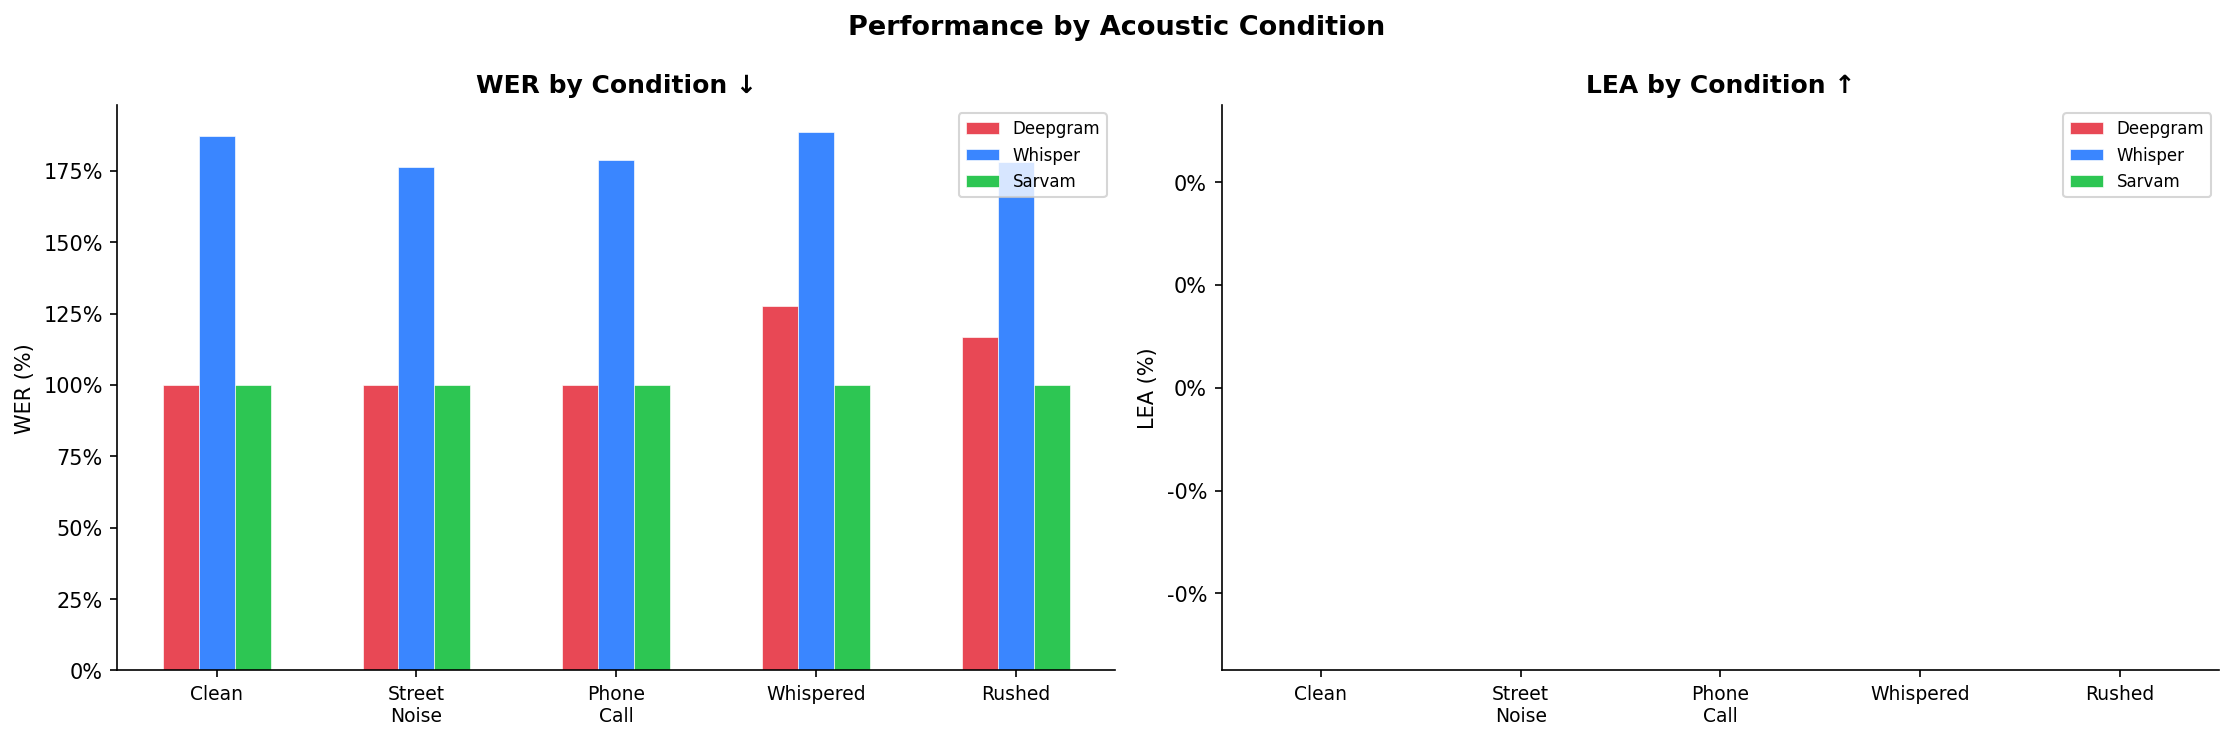


--- cost_vs_accuracy.png ---


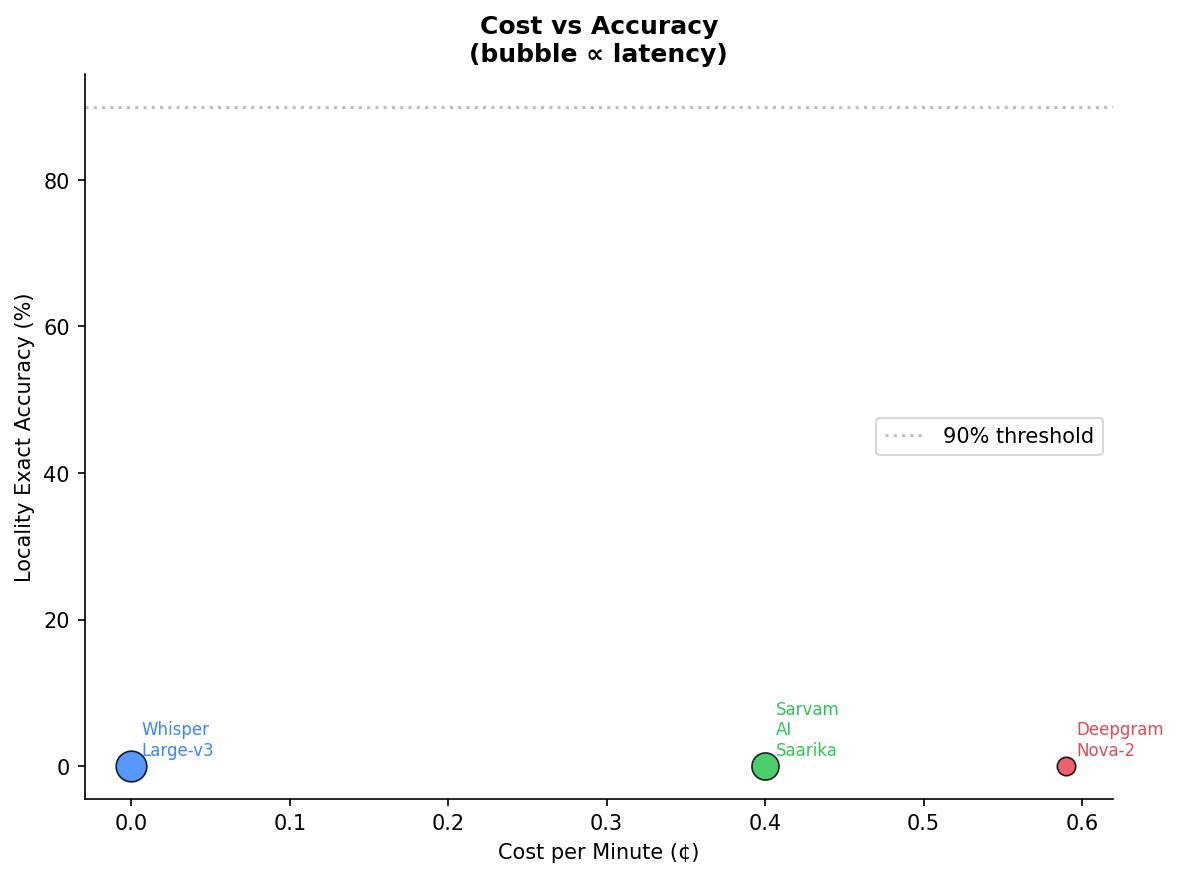


--- latency_comparison.png ---


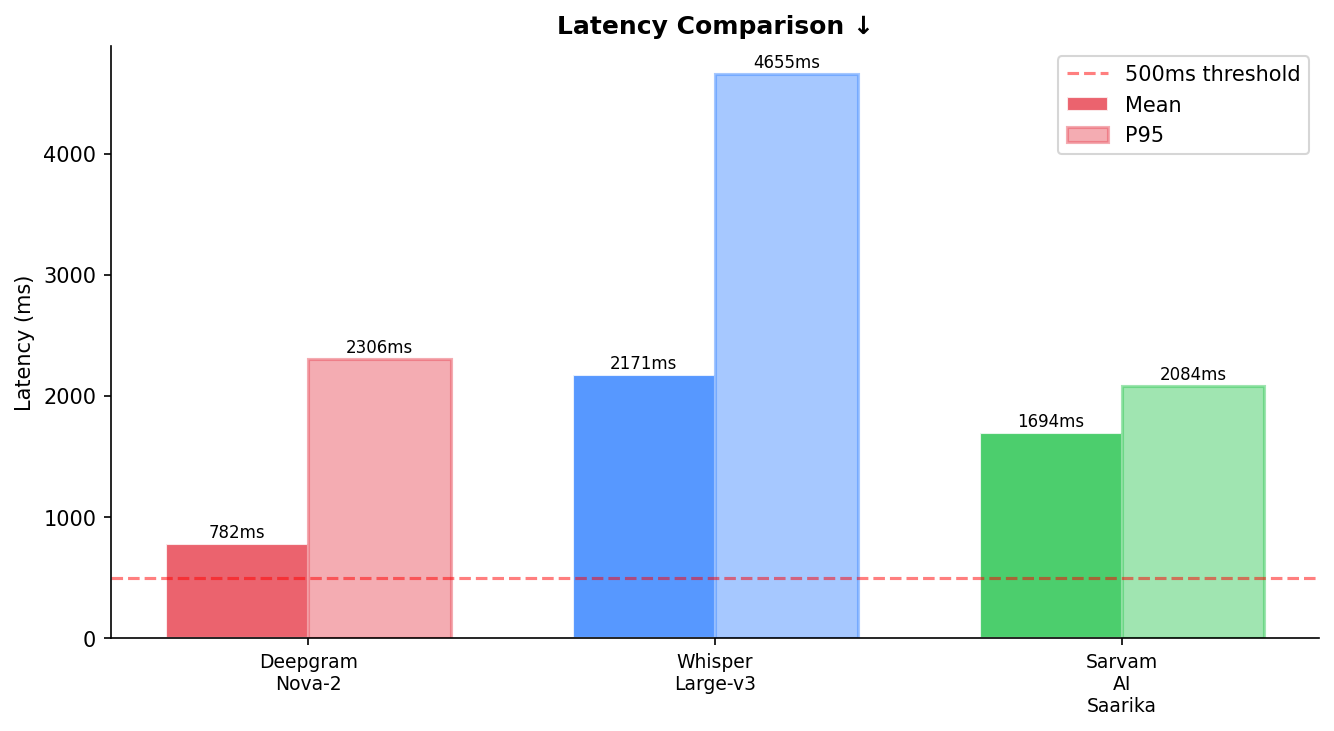


--- lea_heatmap.png ---


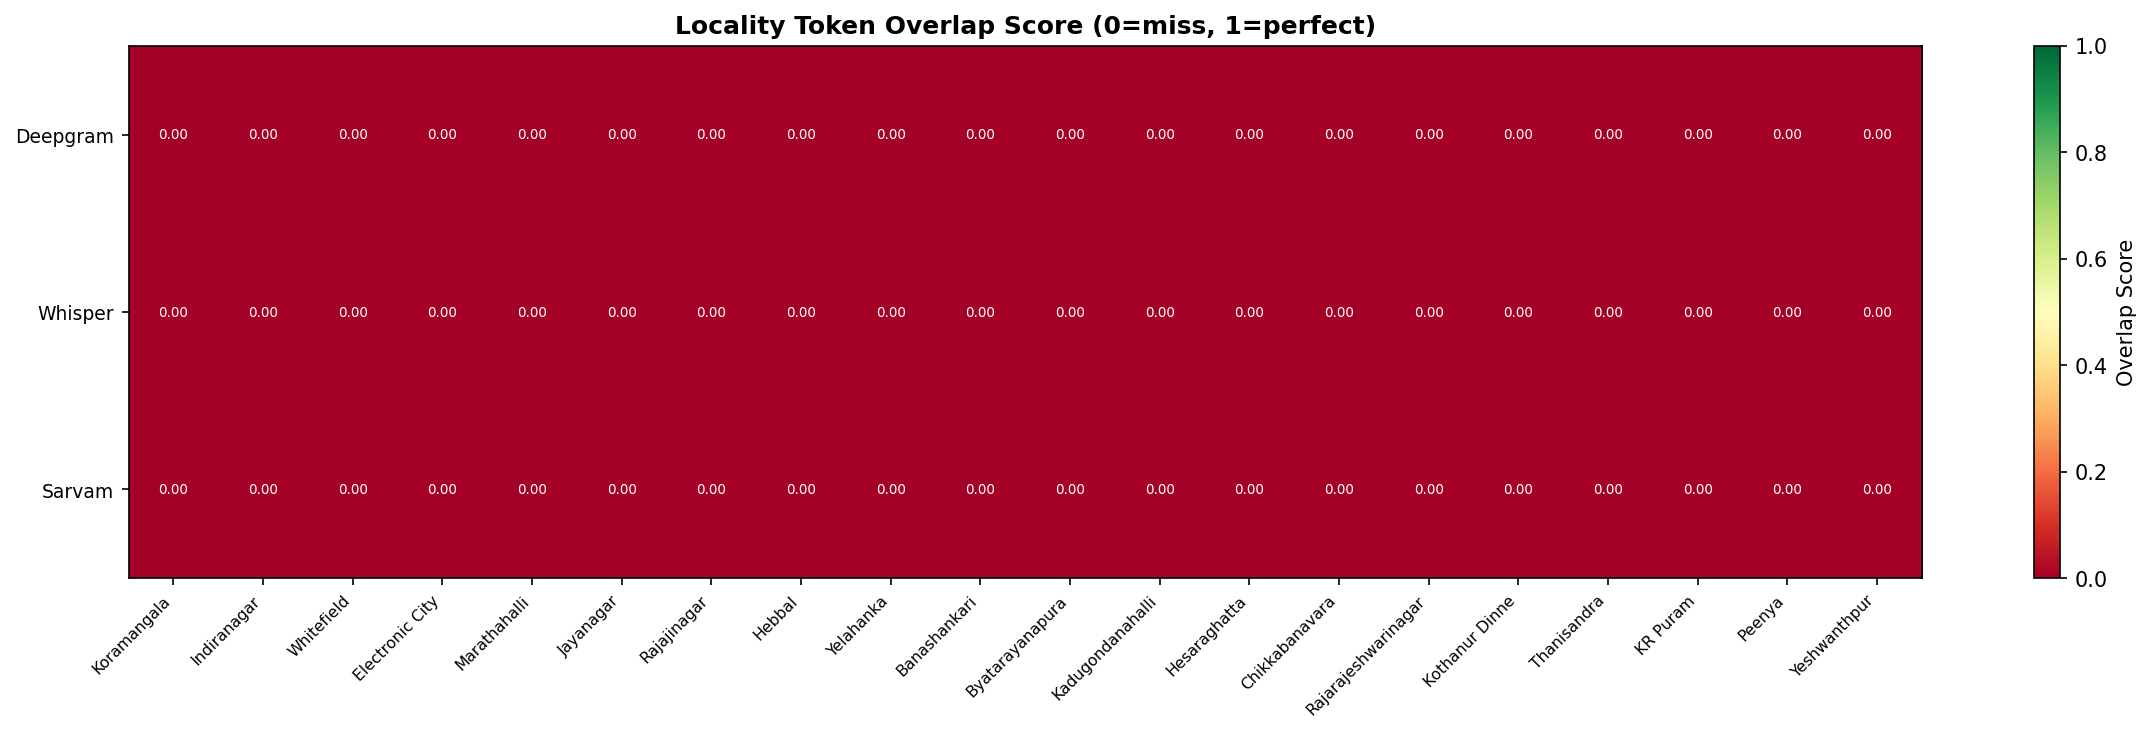


--- overall_comparison.png ---


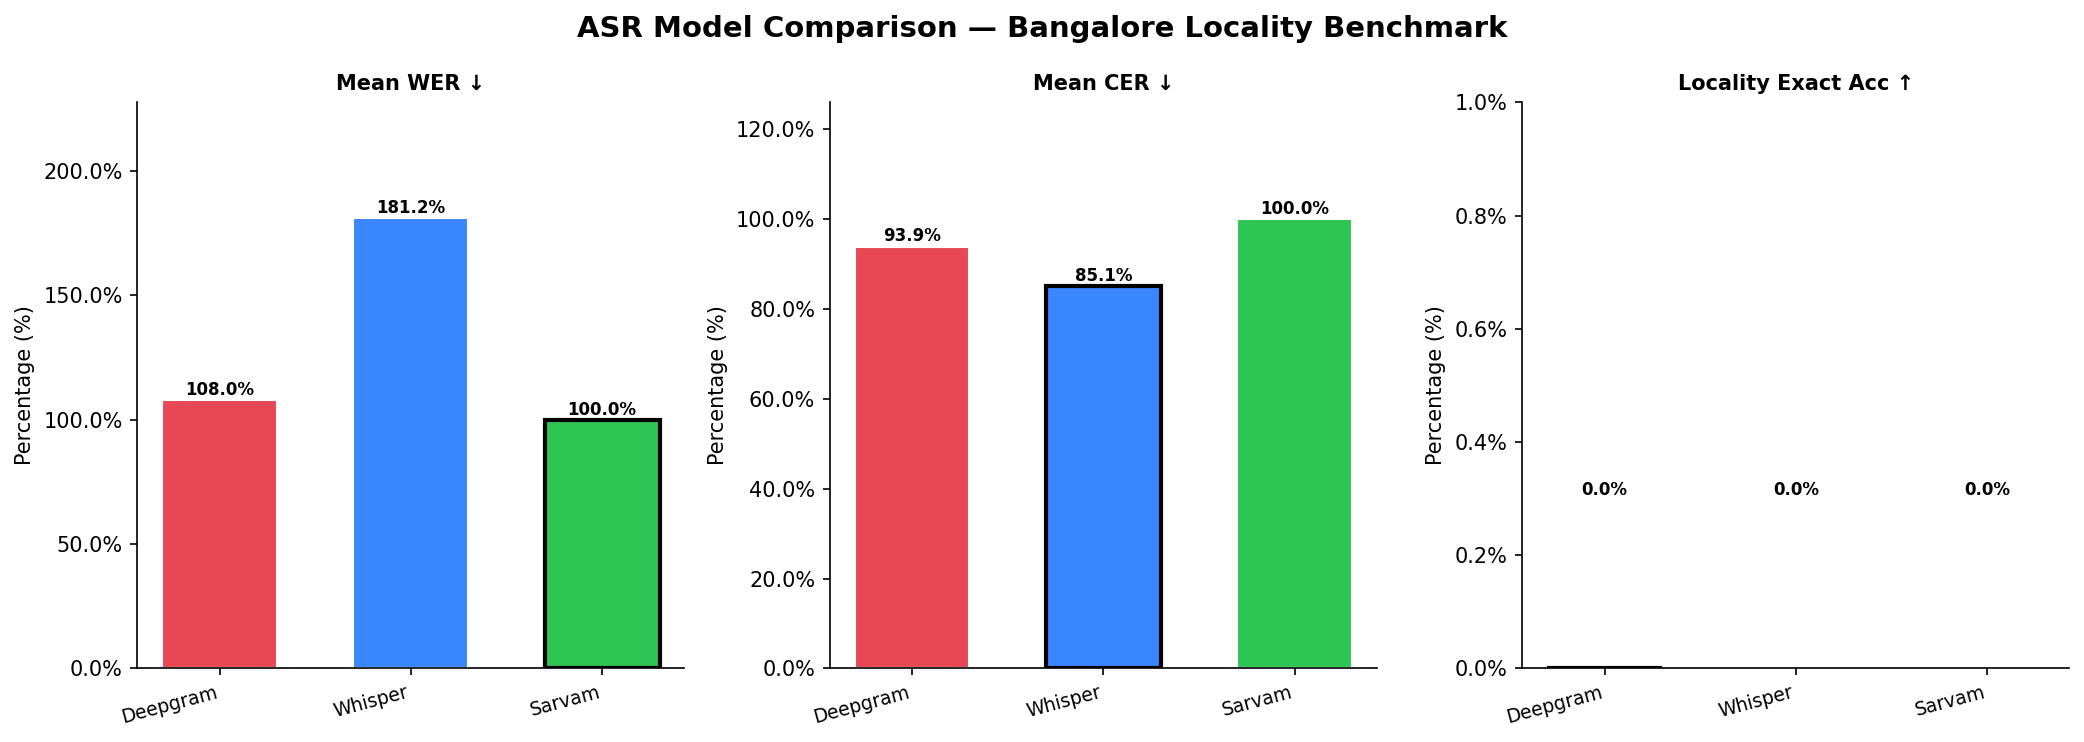


 All charts saved to output/Charts/


In [11]:

CHARTS_DIR = Path(f"./output/Charts")
CHARTS_DIR.mkdir(exist_ok=True)

COLORS = {
    "Deepgram Nova-2":   "#E84855",
    "Whisper Large-v3":  "#3A86FF",
    "Sarvam AI Saarika": "#2DC653",
}
FALLBACK_COLORS = ["#E84855", "#3A86FF", "#2DC653", "#FF9500", "#9B5DE5"]

def model_color(model_name: str, idx: int) -> str:
    return COLORS.get(model_name, FALLBACK_COLORS[idx % len(FALLBACK_COLORS)])

def savefig(name: str):
    path = CHARTS_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"  Saved: {path}")


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("ASR Model Comparison — Bangalore Locality Benchmark", fontsize=14, fontweight="bold")
models = [r["model"] for r in all_results]
colors = [model_color(m, i) for i, m in enumerate(models)]
x = np.arange(len(models))

for ax, (key, title, lower_better) in zip(axes, [
    ("mean_wer",               "Mean WER ↓",             True),
    ("mean_cer",               "Mean CER ↓",             True),
    ("locality_exact_accuracy","Locality Exact Acc ↑",   False),
]):
    values = [r[key] * 100 for r in all_results]
    bars = ax.bar(x, values, color=colors, edgecolor="white", width=0.6)
    best = values.index(min(values) if lower_better else max(values))
    bars[best].set_edgecolor("black"); bars[best].set_linewidth(2)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([m.split()[0] for m in models], rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Percentage (%)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_ylim(0, max(values) * 1.25 + 1)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.tight_layout()
savefig("overall_comparison.png")


conditions   = ["clean", "street_noise", "phone_call", "whispered", "rushed"]
cond_labels  = ["Clean", "Street\nNoise", "Phone\nCall", "Whispered", "Rushed"]
n_models, n_cond = len(all_results), len(conditions)
width, x = 0.18, np.arange(n_cond)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Performance by Acoustic Condition", fontsize=13, fontweight="bold")
for i, r in enumerate(all_results):
    wers = [r.get("condition_breakdown", {}).get(c, {}).get("mean_wer", 0)*100 for c in conditions]
    leas = [r.get("condition_breakdown", {}).get(c, {}).get("locality_exact_accuracy", 0)*100 for c in conditions]
    offset = (i - n_models/2 + 0.5) * width
    col = model_color(r["model"], i)
    ax1.bar(x + offset, wers, width, label=r["model"].split()[0], color=col, edgecolor="white", linewidth=0.3)
    ax2.bar(x + offset, leas, width, label=r["model"].split()[0], color=col, edgecolor="white", linewidth=0.3)
for ax, title, ylabel in [
    (ax1, "WER by Condition ↓", "WER (%)"),
    (ax2, "LEA by Condition ↑", "LEA (%)"),
]:
    ax.set_title(title, fontweight="bold"); ax.set_xticks(x)
    ax.set_xticklabels(cond_labels, fontsize=9); ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(fontsize=8); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
savefig("condition_breakdown.png")


mean_lats = [r.get("mean_latency_ms", 0) for r in all_results]
p95_lats  = [r.get("p95_latency_ms",  0) for r in all_results]
if any(mean_lats):
    fig, ax = plt.subplots(figsize=(9, 5))
    w = 0.35
    b1 = ax.bar(x[:len(all_results)] - w/2, mean_lats, w, label="Mean", color=colors, alpha=0.85, edgecolor="white")
    b2 = ax.bar(x[:len(all_results)] + w/2, p95_lats,  w, label="P95",  color=colors, alpha=0.45,
                edgecolor=colors, linewidth=1.5)
    for bar, val in zip(list(b1)+list(b2), mean_lats+p95_lats):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f"{val:.0f}ms", ha="center", va="bottom", fontsize=8)
    ax.axhline(500, color="red", linestyle="--", alpha=0.5, label="500ms threshold")
    ax.set_title("Latency Comparison ↓", fontweight="bold")
    ax.set_xticks(x[:len(all_results)])
    ax.set_xticklabels([m.replace(" ", "\n") for m in models], fontsize=9)
    ax.set_ylabel("Latency (ms)"); ax.legend()
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    savefig("latency_comparison.png")


localities   = [s["locality"] for s in all_results[0]["per_sample"]]
model_labels = [r["model"].split()[0] for r in all_results]
data = np.array([[s["locality_overlap"] for s in r["per_sample"]] for r in all_results])
fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(localities))); ax.set_xticklabels(localities, rotation=45, ha="right", fontsize=7.5)
ax.set_yticks(range(len(model_labels))); ax.set_yticklabels(model_labels, fontsize=9)
ax.set_title("Locality Token Overlap Score (0=miss, 1=perfect)", fontweight="bold")
for i in range(len(all_results)):
    for j in range(len(localities)):
        val = data[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if val < 0.4 else "black")
plt.colorbar(im, ax=ax, label="Overlap Score")
plt.tight_layout()
savefig("lea_heatmap.png")


fig, ax = plt.subplots(figsize=(8, 6))
for i, r in enumerate(all_results):
    meta = r.get("model_meta", {})
    cost = meta.get("cost_per_min_usd", 0) * 100
    lea  = r["locality_exact_accuracy"] * 100
    lat  = r.get("mean_latency_ms", 500)
    col  = model_color(r["model"], i)
    ax.scatter(cost, lea, s=lat/10, color=col, alpha=0.85, edgecolors="black", linewidth=0.8, zorder=3)
    ax.annotate(r["model"].replace(" ", "\n"), (cost, lea), xytext=(5, 5),
                textcoords="offset points", fontsize=8, color=col)
ax.set_xlabel("Cost per Minute (¢)"); ax.set_ylabel("Locality Exact Accuracy (%)")
ax.set_title("Cost vs Accuracy\n(bubble ∝ latency)", fontweight="bold")
ax.axhline(90, color="gray", linestyle=":", alpha=0.5, label="90% threshold")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
savefig("cost_vs_accuracy.png")


for chart in sorted(CHARTS_DIR.glob("*.png")):
    print(f"\n--- {chart.name} ---")
    display(Image(filename=str(chart)))

print(f"\n All charts saved to {CHARTS_DIR}/")

In [12]:
output_dir = "./output"
zip_filename = "output_archive"

shutil.make_archive(zip_filename, 'zip', output_dir)
print(f"Zipped '{output_dir}' to '{zip_filename}.zip'")

Zipped './output' to 'output_archive.zip'
